In [ ]:
#install PyMC if needed

In [5]:
import sys 
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "ipywidgets", "install", "pymc", "arviz", "geopandas", "shapely", "scipy"])



CalledProcessError: Command '['C:\\Users\\Tosin\\Anaconda3\\Conda\\envs\\chirps_netcdf\\python.exe', '-m', 'pip', 'ipywidgets', 'install', 'pymc', 'arviz', 'geopandas', 'shapely', 'scipy', 'requests']' returned non-zero exit status 1.

In [ ]:
#!pip install PyMC
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])

In [2]:
#Step 1 build annual 2024 dataset
import pandas as pd

panel_path = r"C:\Users\Tosin\Downloads\BMC\panel_A_balanced_zero_weeks_climate_complete.csv"
rain_path  = r"C:\Users\Tosin\Downloads\BMC\rain_weekly_by_municipality_FIXED.csv"

panel = pd.read_csv(panel_path)
rain  = pd.read_csv(rain_path)

rain_small = rain[["CVEGEO", "iso_year", "iso_week", "rain_mm_week"]].copy()
rain_small = rain_small.rename(columns={"CVEGEO": "muni_code"})

panel = panel.merge(rain_small, on=["muni_code", "iso_year", "iso_week"], how="left")

panel_2024 = panel[(panel["iso_year"] == 2024) & (panel["rain_mm_week"].notna())].copy()

annual_2024 = panel_2024.groupby("muni_code", as_index=False).agg(
    cases=("total_cases", "sum"),
    deaths=("deaths", "sum"),
    rain_sum=("rain_mm_week", "sum"),
    temp_mean=("t2m_mean", "mean"),
    rh_mean=("rh2m_mean", "mean"),
    weeks=("iso_week", "nunique"),
)

print(annual_2024.shape)
print(annual_2024[["cases", "rain_sum", "temp_mean", "rh_mean"]].describe())

(2469, 7)
              cases     rain_sum    temp_mean      rh_mean
count   2469.000000  2469.000000  2469.000000  2469.000000
mean     131.818955  1113.059136    21.221246    65.016548
std      643.692840   707.950903     3.487667    10.959416
min        0.000000     0.000000    13.013407    30.311236
25%        0.000000   646.376935    18.503846    58.141896
50%        3.000000   984.821512    20.740632    68.283874
75%       33.000000  1493.639955    23.862967    74.008846
max    16532.000000  4196.434365    28.810604    83.734093


In [4]:
#Step 2 load shapefile and join annual data
import geopandas as gpd
#import pandas as pd

shp_path = r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp"

mun = gpd.read_file(shp_path)

mun["muni_code"] = pd.to_numeric(mun["CVEGEO"], errors="coerce").astype("Int64")
gdf = mun.merge(annual_2024, on="muni_code", how="inner").copy()

gdf = gdf.sort_values("muni_code").reset_index(drop=True)

print(gdf.shape)
print(gdf.crs)

(2469, 12)
PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [5]:
#Step 3 build adjacency matrix from polygons: This builds a Queen style neighbor list using a spatial index, then converts to a sparse adjacency matrix.

import numpy as np
import scipy.sparse as sp

sindex = gdf.sindex
geoms = gdf.geometry

neighbors = []
for i, geom in enumerate(geoms):
    cand = list(sindex.intersection(geom.bounds))
    cand = [j for j in cand if j != i]
    neigh = []
    for j in cand:
        if geom.touches(geoms.iloc[j]):
            neigh.append(j)
    neighbors.append(neigh)

deg = np.array([len(n) for n in neighbors])
print("min degree", deg.min(), "mean degree", float(deg.mean()), "max degree", deg.max())
print("isolates", int((deg == 0).sum()))

row = []
col = []
dat = []
for i, neigh in enumerate(neighbors):
    for j in neigh:
        row.append(i)
        col.append(j)
        dat.append(1)

W = sp.csr_matrix((dat, (row, col)), shape=(gdf.shape[0], gdf.shape[0]))
W = ((W + W.T) > 0).astype(float).tocsr()

min degree 0 mean degree 4.619684082624544 max degree 22
isolates 68


In [6]:
# since we have isolates, connect each isolate to its nearest centroid neighbor:
from sklearn.neighbors import NearestNeighbors

cent = gdf.geometry.centroid
coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])

deg = np.array(W.sum(axis=1)).reshape(-1)
iso = np.where(deg == 0)[0]

nn = NearestNeighbors(n_neighbors=2).fit(coords)
idxs = nn.kneighbors(coords, return_distance=False)

W_lil = W.tolil()
for i in iso:
    j = int(idxs[i, 1])
    W_lil[i, j] = 1
    W_lil[j, i] = 1
W = W_lil.tocsr()

deg2 = np.array(W.sum(axis=1)).reshape(-1)
print("isolates after fix", int((deg2 == 0).sum()))

isolates after fix 0


In [7]:
#import sys, subprocess
#subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])

0

In [8]:
#Step 4 fit a spatial CAR Negative Binomial model in PyMC
#We include climate covariates and a spatially structured random effect u.

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az


y = gdf["cases"].to_numpy(dtype=int)

X = gdf[["temp_mean", "rain_sum", "rh_mean"]].copy()
Xz = X.sub(X.mean()).div(X.std(ddof=0)).to_numpy()

n = gdf.shape[0]

coords = {"muni": np.arange(n), "cov": ["temp_z", "rain_z", "rh_z"]}

with pm.Model(coords=coords) as model:
    X_data = pm.Data("X", Xz, dims=("muni", "cov"))
    y_data = pm.Data("y", y, dims="muni")

    intercept = pm.Normal("intercept", 0, 2)
    beta = pm.Normal("beta", 0, 1, dims="cov")

    alpha = pm.Beta("alpha", 2, 2)
    tau = pm.HalfNormal("tau", 1.0)

    u = pm.CAR("u", mu=pt.zeros(n), W=W, alpha=alpha, tau=tau, dims="muni")

    eta = intercept + pt.dot(X_data, beta) + u
    mu  = pm.Deterministic("mu", pt.exp(eta), dims="muni")

    disp = pm.HalfNormal("disp", 2.0)
    pm.NegativeBinomial("cases", mu=mu, alpha=disp, observed=y_data, dims="muni")

    approx = pm.fit(30000, method="advi")
    idata  = approx.sample(1500)

print(az.summary(idata, var_names=["intercept", "beta", "alpha", "tau", "disp"]))

Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 100% 0:00:01 Average Loss = 9,074.4

Finished [100%]: Average Loss = 9,074.3
arviz - WARNING - Shape validation failed: input_shape: (1, 1500), minimum_shape: (chains=2, draws=4)


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept     2.763  0.041   2.685    2.836      0.001    0.001    1446.0   
beta[temp_z]  1.283  0.043   1.203    1.362      0.001    0.001    1557.0   
beta[rain_z] -0.170  0.044  -0.257   -0.090      0.001    0.001    1503.0   
beta[rh_z]   -0.103  0.048  -0.188   -0.012      0.001    0.001    1447.0   
alpha         0.909  0.016   0.881    0.938      0.000    0.000    1319.0   
tau           0.125  0.004   0.118    0.133      0.000    0.000    1415.0   
disp          0.336  0.012   0.315    0.357      0.000    0.000    1460.0   

              ess_tail  r_hat  
intercept       1213.0    NaN  
beta[temp_z]    1356.0    NaN  
beta[rain_z]    1536.0    NaN  
beta[rh_z]      1365.0    NaN  
alpha           1370.0    NaN  
tau             1399.0    NaN  
disp            1367.0    NaN  


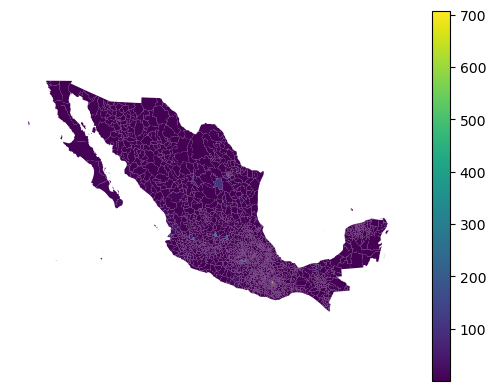

In [9]:
import numpy as np

u_post = idata.posterior["u"].to_numpy()
u_mean = u_post.mean(axis=(0, 1))
rr_mean = np.exp(u_mean)

gdf_map = gdf.copy()
gdf_map["rr_mean"] = rr_mean

ax = gdf_map.plot(column="rr_mean", legend=True)
ax.set_axis_off()

In [10]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az

y = gdf["cases"].to_numpy(dtype=int)

X = gdf[["temp_mean", "rain_sum", "rh_mean"]].copy()
Xz = X.sub(X.mean()).div(X.std(ddof=0)).to_numpy()

n = gdf.shape[0]

coords = {"muni": np.arange(n), "cov": ["temp_z", "rain_z", "rh_z"]}

with pm.Model(coords=coords) as model:
    X_data = pm.Data("X", Xz, dims=("muni", "cov"))
    y_data = pm.Data("y", y, dims="muni")

    intercept = pm.Normal("intercept", 0, 2)
    beta = pm.Normal("beta", 0, 1, dims="cov")

    alpha = pm.Beta("alpha", 2, 2)
    tau = pm.HalfNormal("tau", 1.0)
    u = pm.CAR("u", mu=pt.zeros(n), W=W, alpha=alpha, tau=tau, dims="muni")

    eta = intercept + pt.dot(X_data, beta) + u
    mu = pm.Deterministic("mu", pt.exp(eta), dims="muni")

    disp = pm.HalfNormal("disp", 2.0)
    pm.NegativeBinomial("cases", mu=mu, alpha=disp, observed=y_data, dims="muni")

    cb = pm.callbacks.CheckParametersConvergence(tolerance=1e-3)
    approx = pm.fit(4000, method="advi", callbacks=[cb])
    idata = approx.sample(800)

az.summary(idata, var_names=["intercept", "beta", "alpha", "tau", "disp"])

Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 100% 0:00:01 Average Loss = 50,032

Finished [100%]: Average Loss = 49,416
arviz - WARNING - Shape validation failed: input_shape: (1, 800), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,1.173,0.550,0.194,2.210,0.022,0.014,633.0,653.0,NaN
beta[temp_z],0.907,0.486,0.016,1.774,0.017,0.013,780.0,804.0,NaN
beta[rain_z],-0.327,0.411,-1.072,0.451,0.015,0.011,750.0,718.0,NaN
beta[rh_z],-0.283,0.397,-1.034,0.459,0.015,0.010,728.0,666.0,NaN
alpha,0.570,0.127,0.338,0.798,0.004,0.003,843.0,762.0,NaN
tau,0.531,0.225,0.172,0.924,0.008,0.008,726.0,699.0,NaN
disp,0.750,0.444,0.163,1.547,0.016,0.026,806.0,726.0,NaN


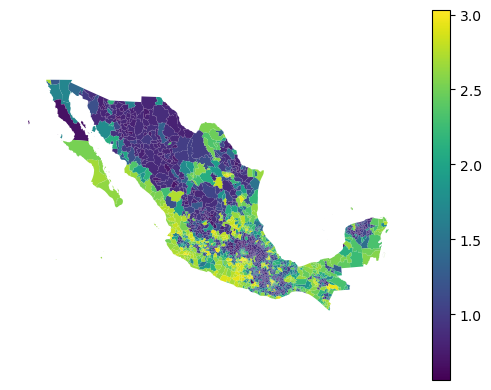

In [11]:
import numpy as np

u_post = idata.posterior["u"].to_numpy()
u_mean = u_post.mean(axis=(0, 1))
rr_mean = np.exp(u_mean)

gdf_map = gdf.copy()
gdf_map["rr_mean"] = rr_mean

ax = gdf_map.plot(column="rr_mean", legend=True)
ax.set_axis_off()